<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/ANOVA_dos_v%C3%ADas_sin_interac_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

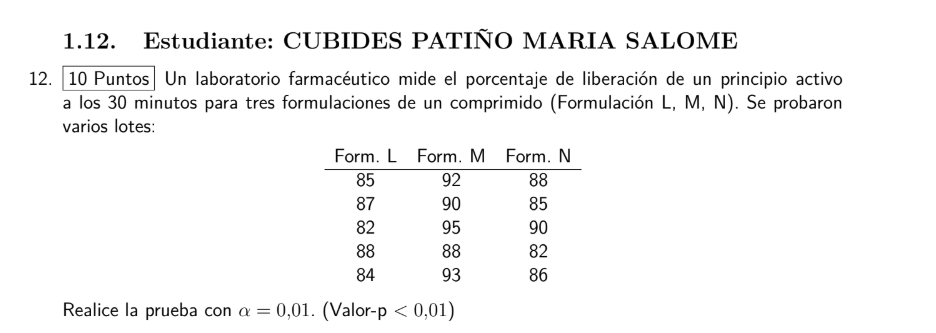

DATOS ORIGINALES (Lotes como filas, Formulaciones como columnas):
    L   M   N
0  85  92  88
1  87  90  85
2  82  95  90
3  88  88  82
4  84  93  86


Media Global: 87.6667

Medias por Formulación:
  L: 85.2000
  M: 91.6000
  N: 86.2000


TABLA ANOVA DE UNA VÍA
Fuente de Variación            SC     gl           CM            F      Valor-p    F crítico
----------------------------------------------------------------------------------------------------
Formulaciones            118.5333      2      59.2667       8.0090     0.006173       6.9266
Error                     88.8000     12       7.4000
Total                    207.3333     14

INTERPRETACIÓN (α = 0.01):
--------------------------------------------------------------------------------

EFECTO DE FORMULACIONES:
   F calculado = 8.0090
   F crítico   = 6.9266
   Valor-p     = 0.006173
   ✓ Hay diferencia significativa entre las formulaciones (p < 0.01)


RESPUESTA A LA PREGUNTA:
--------------------------------------------------

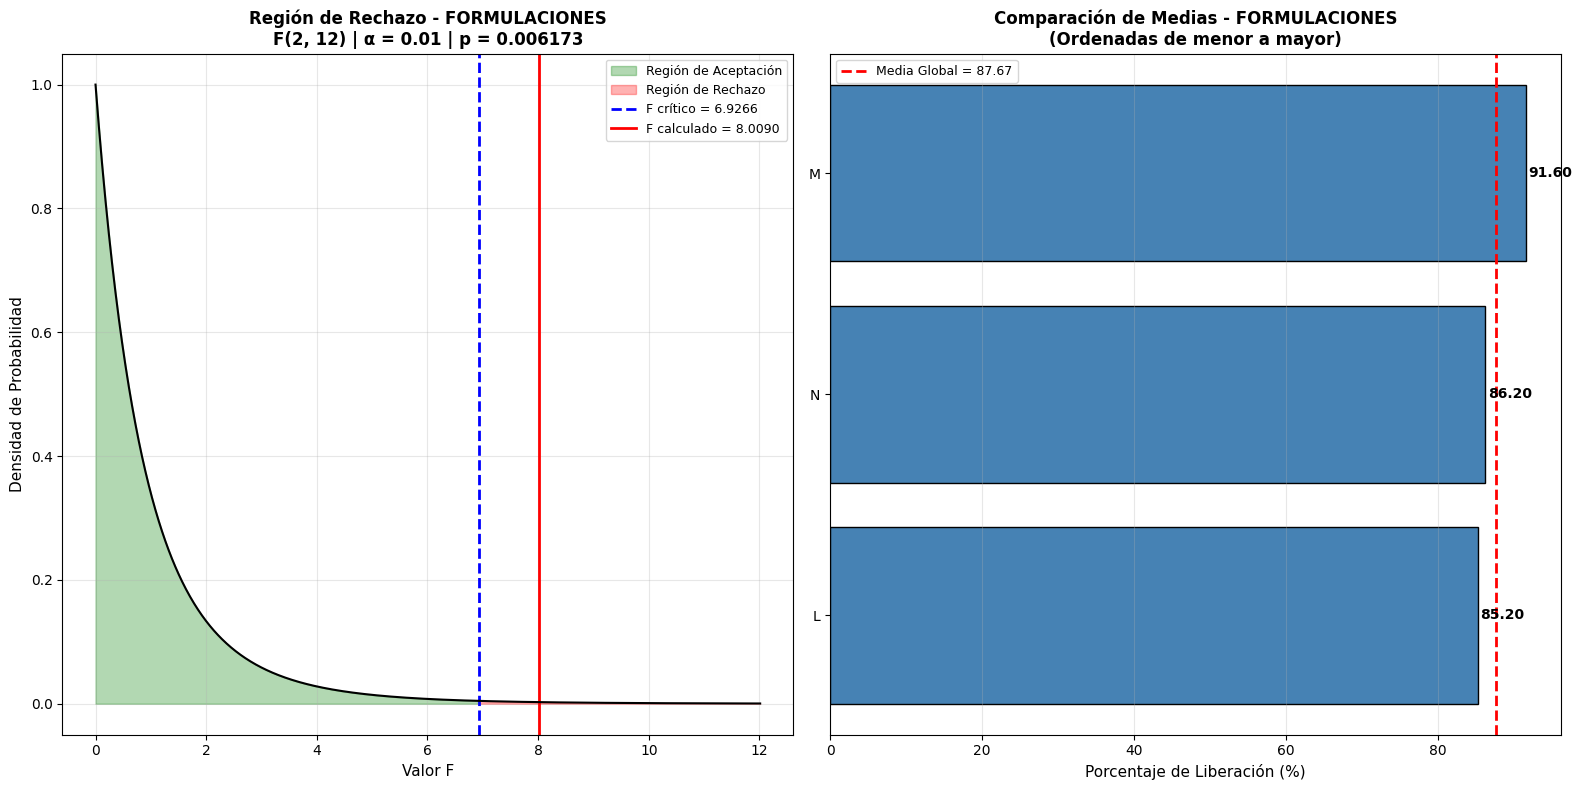

✓ Gráfico guardado como 'tukey_matriz_diferencias.png'


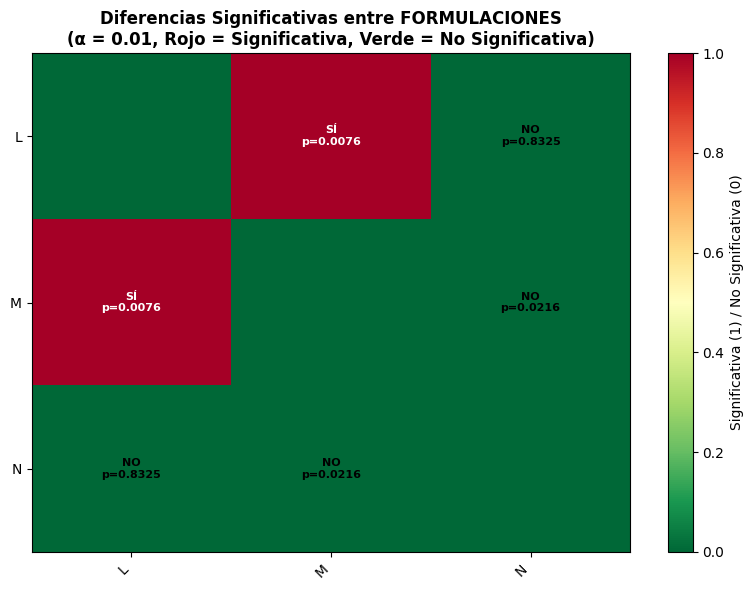


ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from itertools import combinations

# Datos del problema
formulaciones = ['L', 'M', 'N']

# Matriz de porcentajes de liberación (filas: formulaciones, columnas: lotes)
datos = np.array([
    [85, 87, 82, 88, 84],  # Formulación L
    [92, 90, 95, 88, 93],  # Formulación M
    [88, 85, 90, 82, 86]   # Formulación N
])

# Crear DataFrame para mejor visualización
df = pd.DataFrame(datos.T, columns=formulaciones)
print("DATOS ORIGINALES (Lotes como filas, Formulaciones como columnas):")
print(df)
print("\n" + "="*80 + "\n")

# Preparar datos para ANOVA
n_grupos = len(formulaciones) # k en ANOVA de una vía
n_observaciones_por_grupo = datos.shape[1] # n en ANOVA de una vía (muestras por grupo)
n_total = n_grupos * n_observaciones_por_grupo # N en ANOVA de una vía

# Calcular medias
media_global = np.mean(datos)
medias_grupos = np.mean(datos, axis=1) # Medias para cada formulación

print(f"Media Global: {media_global:.4f}")
print(f"\nMedias por Formulación:")
for i, form in enumerate(formulaciones):
    print(f"  {form}: {medias_grupos[i]:.4f}")
print("\n" + "="*80 + "\n")

# ============================================================================
# ANOVA DE UNA VÍA
# ============================================================================

# Suma de cuadrados total (SCT)
SCT = np.sum((datos - media_global)**2)

# Suma de cuadrados de tratamientos (SST - entre grupos)
SST = n_observaciones_por_grupo * np.sum((medias_grupos - media_global)**2)

# Suma de cuadrados del error (SSE - dentro de grupos)
SSE = SCT - SST

# Grados de libertad
gl_grupos = n_grupos - 1
gl_error = n_total - n_grupos
gl_total = n_total - 1

# Cuadrados medios
CMT = SST / gl_grupos # Cuadrado Medio de Tratamientos
CME = SSE / gl_error  # Cuadrado Medio del Error

# Estadístico F
F_calculado = CMT / CME

# Valor p
p_valor = 1 - stats.f.cdf(F_calculado, gl_grupos, gl_error)

# Valor crítico F para α = 0.01
alpha = 0.01
F_critico = stats.f.ppf(1 - alpha, gl_grupos, gl_error)

# Crear tabla ANOVA
print("TABLA ANOVA DE UNA VÍA")
print("="*100)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12} {'F crítico':>12}")
print("-"*100)
print(f"{'Formulaciones':<20} {SST:>12.4f} {gl_grupos:>6} {CMT:>12.4f} {F_calculado:>12.4f} {p_valor:>12.6f} {F_critico:>12.4f}")
print(f"{'Error':<20} {SSE:>12.4f} {gl_error:>6} {CME:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_total:>6}")
print("="*100)

# Interpretación de resultados
print(f"\nINTERPRETACIÓN (α = {alpha}):")
print("-" * 80)

print(f"\nEFECTO DE FORMULACIONES:")
print(f"   F calculado = {F_calculado:.4f}")
print(f"   F crítico   = {F_critico:.4f}")
print(f"   Valor-p     = {p_valor:.6f}")
if p_valor < alpha:
    print(f"   ✓ Hay diferencia significativa entre las formulaciones (p < {alpha})")
else:
    print(f"   ✗ No hay diferencia significativa entre las formulaciones (p ≥ {alpha})")

print("\n" + "="*80)
print("\nRESPUESTA A LA PREGUNTA:")
print("-" * 80)
print("\n¿Hay diferencia significativa en el porcentaje de liberación de las tres formulaciones?")
if p_valor < alpha:
    print(f"SÍ, hay evidencia estadística significativa (p = {p_valor:.6f} < {alpha})")
else:
    print(f"NO, no hay evidencia estadística significativa (p = {p_valor:.6f} ≥ {alpha})")

# ============================================================================
# PRUEBA DE TUKEY (HSD - Honestly Significant Difference)
# ============================================================================

if p_valor < alpha: # Solo realizar Tukey si el ANOVA global es significativo
    print("\n" + "="*80)
    print("PRUEBA DE TUKEY (HSD)")
    print("="*80)

    print("\n" + "-"*80)
    print("COMPARACIONES MÚLTIPLES PARA FORMULACIONES:")
    print("-"*80)

    q_valor = stats.studentized_range.ppf(1 - alpha, n_grupos, gl_error)
    HSD_valor = q_valor * np.sqrt(CME / n_observaciones_por_grupo)

    print(f"\nValor crítico q (α={alpha}, k={n_grupos}, gl_error={gl_error}): {q_valor:.4f}")
    print(f"HSD (Diferencia Honestamente Significativa): {HSD_valor:.4f}")
    print(f"\n{'Form. i':<15} {'Form. j':<15} {'Media i':>10} {'Media j':>10} "
          f"{'Diferencia':>12} {'|Dif|':>10} {'q_obs':>8} {'p-valor':>10} {'Significativa':>15}")
    print("-"*115)

    comparaciones_formulaciones = []
    for i, j in combinations(range(n_grupos), 2):
        diff    = medias_grupos[i] - medias_grupos[j]
        abs_diff = abs(diff)
        q_obs   = abs_diff / np.sqrt(CME / n_observaciones_por_grupo)
        p_val   = 1 - stats.studentized_range.cdf(q_obs, n_grupos, gl_error)

        es_sig  = "SÍ" if p_val < alpha else "NO"
        comparaciones_formulaciones.append({
            'Form_i': formulaciones[i], 'Form_j': formulaciones[j],
            'Media_i': medias_grupos[i], 'Media_j': medias_grupos[j],
            'Diferencia': diff, 'Abs_Diferencia': abs_diff,
            'q_obs': q_obs, 'p_valor': p_val, 'Significativa': es_sig
        })
        print(f"{formulaciones[i]:<15} {formulaciones[j]:<15} {medias_grupos[i]:>10.4f} {medias_grupos[j]:>10.4f} "
              f"{diff:>12.4f} {abs_diff:>10.4f} {q_obs:>8.4f} {p_val:>10.6f} {es_sig:>15}")
else:
    print(f"\nNo es necesario realizar la prueba de Tukey, ya que el ANOVA no mostró diferencias significativas (p >= {alpha}).")

# ============================================================================
# GRÁFICOS DE REGIÓN DE RECHAZO Y MEDIAS
# ============================================================================

print("\n" + "="*80)
print("GENERANDO GRÁFICOS...")
print("="*80)

fig = plt.figure(figsize=(16, 8)) # Ajustar el tamaño de la figura

# --- Gráfico 1: Región de rechazo para FORMULACIONES ---
ax1 = plt.subplot(1, 2, 1) # Un solo gráfico de región de rechazo
x = np.linspace(0, max(F_calculado, F_critico) * 1.5, 1000)
y = stats.f.pdf(x, gl_grupos, gl_error)

x_accept = x[x <= F_critico]
ax1.fill_between(x_accept, 0, stats.f.pdf(x_accept, gl_grupos, gl_error),
                 alpha=0.3, color='green', label='Región de Aceptación')
x_reject = x[x >= F_critico]
ax1.fill_between(x_reject, 0, stats.f.pdf(x_reject, gl_grupos, gl_error),
                 alpha=0.3, color='red', label='Región de Rechazo')
ax1.axvline(F_critico, color='blue', linestyle='--', linewidth=2,
            label=f'F crítico = {F_critico:.4f}')
ax1.axvline(F_calculado, color='red', linestyle='-', linewidth=2,
            label=f'F calculado = {F_calculado:.4f}')
ax1.plot(x, y, 'k-', linewidth=1.5)
ax1.set_xlabel('Valor F', fontsize=11)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=11)
ax1.set_title(f'Región de Rechazo - FORMULACIONES\nF({gl_grupos}, {gl_error}) | α = {alpha} | p = {p_valor:.6f}',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Medias por FORMULACIÓN ---
ax2 = plt.subplot(1, 2, 2) # Un solo gráfico de barras
formulaciones_ordenadas = sorted(range(n_grupos), key=lambda i: medias_grupos[i])
medias_ord_formulaciones = [medias_grupos[i] for i in formulaciones_ordenadas]
nombres_ord_formulaciones = [formulaciones[i] for i in formulaciones_ordenadas]

bars2 = ax2.barh(nombres_ord_formulaciones, medias_ord_formulaciones, color='steelblue', edgecolor='black')
ax2.axvline(media_global, color='red', linestyle='--', linewidth=2,
            label=f'Media Global = {media_global:.2f}')
ax2.set_xlabel('Porcentaje de Liberación (%)', fontsize=11)
ax2.set_title('Comparación de Medias - FORMULACIONES\n(Ordenadas de menor a mayor)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars2, medias_ord_formulaciones):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
             va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('anova_un_via_analisis.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráfico guardado como 'anova_un_via_analisis.png'")
plt.show()

# ============================================================================
# MATRIZ DE DIFERENCIAS SIGNIFICATIVAS (Tukey)
# ============================================================================

if p_valor < alpha: # Solo generar la matriz si Tukey fue realizado
    fig2, ax_matrix = plt.subplots(1, 1, figsize=(8, 6)) # Un solo gráfico de matriz

    # --- Matriz FORMULACIONES ---
    diff_matrix_formulaciones = np.zeros((n_grupos, n_grupos))
    for i in range(n_grupos):
        for j in range(n_grupos):
            if i != j:
                diff = abs(medias_grupos[i] - medias_grupos[j])
                q_ij  = diff / np.sqrt(CME / n_observaciones_por_grupo)
                p_ij  = 1 - stats.studentized_range.cdf(q_ij, n_grupos, gl_error)
                diff_matrix_formulaciones[i, j] = 1 if p_ij < alpha else 0

    im = ax_matrix.imshow(diff_matrix_formulaciones, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax_matrix.set_xticks(range(n_grupos))
    ax_matrix.set_yticks(range(n_grupos))
    ax_matrix.set_xticklabels(formulaciones, rotation=45, ha='right')
    ax_matrix.set_yticklabels(formulaciones)
    ax_matrix.set_title(f'Diferencias Significativas entre FORMULACIONES\n(α = {alpha}, Rojo = Significativa, Verde = No Significativa)',
                  fontsize=12, fontweight='bold')
    for i in range(n_grupos):
        for j in range(n_grupos):
            if i != j:
                q_ij  = abs(medias_grupos[i] - medias_grupos[j]) / np.sqrt(CME / n_observaciones_por_grupo)
                p_ij  = 1 - stats.studentized_range.cdf(q_ij, n_grupos, gl_error)
                label = f"{'SÍ' if p_ij < alpha else 'NO'}\np={p_ij:.4f}"
                color_text = 'black' if p_ij >= alpha else 'white'
                ax_matrix.text(j, i, label, ha='center', va='center',
                               color=color_text, fontweight='bold', fontsize=8)
    plt.colorbar(im, ax=ax_matrix, label='Significativa (1) / No Significativa (0)')

    plt.tight_layout()
    plt.savefig('tukey_matriz_diferencias.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico guardado como 'tukey_matriz_diferencias.png'")
    plt.show()

print("\n" + "="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)

##Planteamiento del problema
Un laboratorio farmacéutico quiere determinar si existen diferencias significativas en el porcentaje de liberación del principio activo entre tres formulaciones de comprimidos: L, M y N.

Se trabaja con:

Nivel de significancia: α=0.01
Método: ANOVA de una vía

##Hipótesis
##Hipótesis nula H0

Las medias de liberación de las tres formulaciones son iguales.

H0: μL=μM=μN
	​


##Hipótesis alternativa H1

Al menos una media es diferente.



##Nivel de significancia
α=0.01 USAMOS ese nivel de significancia

Esto significa que se acepta un 1% de probabilidad de cometer error tipo I, es decir, rechazar H0 siendo verdadera

Conclusiones principales:


*   El estadístico utilizado es la distribución F de Fisher porque se están comparando más de dos medias.
*   Tukey HSD=6.1386 Eso significa que para decir que dos formulaciones son significativamente diferentes, la diferencia entre sus medias debe ser mayor a ESO. L vs M si hay diferencia significativa, L vs N no hay y M vs N no significativa al 1%.
*   El F calculado es mayor que el F critico o sea se RECHAZA H0, además el valor p= 0.006173<0.01 existe evidencia estadística suficiente para rechazar la hipótesis nula.
*  Sí existe diferencia significativa entre las formulaciones del comprimido respecto al porcentaje de liberación del principio activo a los 30 minutos. L= 85.2, M=91.6 y N=86.2. Por lo tanto, la formulación M parece tener un comportamiento diferente frente a las otras formulaciones.
